In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"E:\Data Science\example files\Sample Data\BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

X = df.drop("medv", axis=1)
y = df['medv']

scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=0.8, random_state=42)

ln_model = LinearRegression()
ln_model.fit(X_train, y_train)

y_pred = ln_model.predict(X_test)

In [4]:
print(f"RMSE: {mean_squared_error(y_test, y_pred)**0.5}")

RMSE: 4.928602182665338


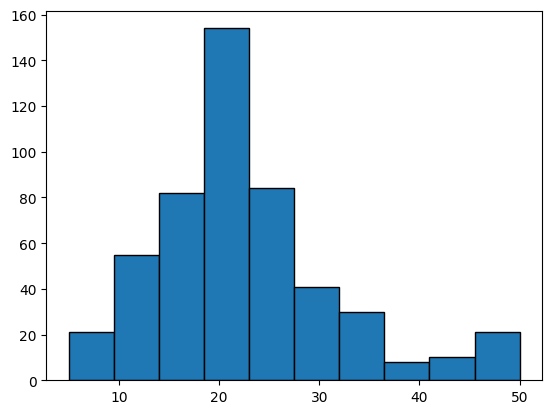

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['medv'], edgecolor='black')
plt.show()

In [6]:
from sklearn.pipeline import Pipeline
import joblib

pipeline = Pipeline([
    ('sclar', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

joblib.dump(pipeline, "boston_model.pkl")

['boston_model.pkl']

In [7]:
# quick test
model = joblib.load("boston_model.pkl")

predictions = model.predict(X_test[:1])
print(predictions)

[28.99672362]


In [15]:
val = df.loc[0].values

In [17]:
X_test[:1]

array([[-0.40983668, -0.48772236, -1.03402724, -0.27259857, -0.38609067,
         0.18715116,  0.55208139, -0.54607682, -0.52300145, -0.66660821,
        -0.85792914,  0.42570183, -0.50645674]])